# 🔍 Notebook 1 — Exploration du jeu de données d'emails de phishing

Dans le notebook précédent, tu as appris ce qu'est le phishing et tu as
regardé quelques exemples à la main. Maintenant, nous allons **explorer le
jeu de données complet** avec du code et des visualisations pour découvrir
des motifs (patterns) qui pourraient aider un modèle de machine learning
à distinguer les emails sûrs du phishing.

---

## Ce que tu vas apprendre dans ce notebook

1. Si les deux classes sont équilibrées ou non.
2. Si les emails de phishing sont plus courts ou plus longs que les emails sûrs.
3. Quels mots apparaissent le plus souvent dans chaque classe.
4. Comment faire un nettoyage basique du texte (tokenisation).
5. Comment repérer des échantillons bruités ou mal étiquetés.

À la fin, tu devrais pouvoir répondre à des questions comme :
- *\"Les emails de phishing sont-ils plus courts ?\"*
- *\"Quels mots sont typiques du phishing ?\"*
- *\"Y a-t-il des emails qui semblent mal étiquetés ?\"*

---

## 0 — Mise en place

Importons les bibliothèques nécessaires et chargeons les données.

In [2]:
# pandas : pour manipuler des tableaux de données (comme Excel, mais en code).
import pandas as pd

# matplotlib : pour créer des graphiques (histogrammes, camemberts, etc.).
import matplotlib.pyplot as plt

# numpy : pour faire des calculs mathématiques sur des tableaux de nombres.
import numpy as np

# Counter : un outil qui compte combien de fois chaque élément apparaît dans une liste.
from collections import Counter

# re : pour chercher des motifs dans du texte (par ex. trouver toutes les URLs).
import re

# On désactive les avertissements pour ne pas encombrer l'affichage.
import warnings
warnings.filterwarnings("ignore")

# On configure l'apparence des graphiques par défaut :
# taille, taille du texte, quadrillage, etc.
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 13,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# On définit les couleurs qu'on utilisera partout : vert pour sûr, rouge pour phishing.
COLORS = {"safe": "#2ecc71", "phishing": "#e74c3c"}

# On charge le jeu de données nettoyé.
df = pd.read_csv("data_exploration/emails_clean.csv")
print(f"{len(df):,} emails chargés.")
df.head(3)

5,806 emails chargés.


,text,label
0,">>>>> ""J"" == James Rogers writes: J> ... ...",0
1,"""This is a very tenuous time for Microsoft,"" G...",0
2,I rigged this up for testing before I commit t...,0


---

## 1 — Équilibre des classes

La première chose à vérifier dans tout problème de classification est :
**combien d'exemples avons-nous pour chaque classe ?**

Si une classe est beaucoup plus grande que l'autre, le modèle pourrait
\"tricher\" en prédisant toujours la classe majoritaire et obtenir quand même
une bonne précision.

Par exemple, si 95% des emails sont sûrs, un modèle qui **dit toujours \"sûr\"**
aurait 95% de précision — mais il raterait chaque email de phishing !

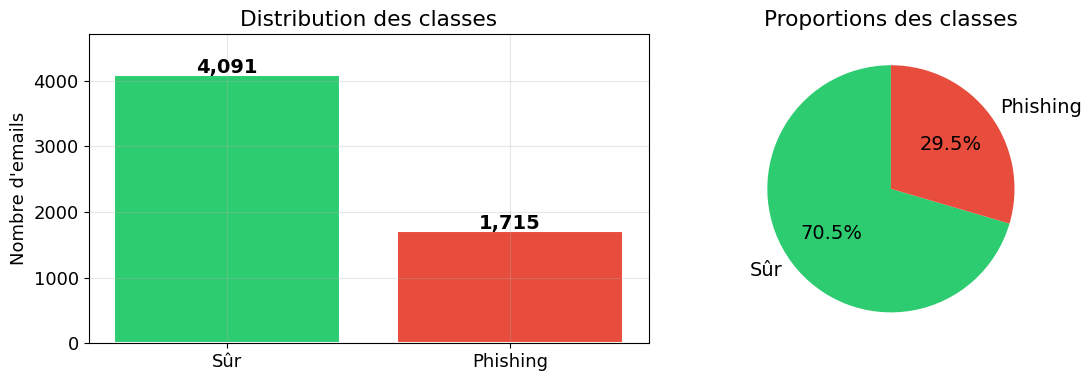

Ratio d'équilibre (minorité / majorité) : 0.42
Si ratio > 0.8 → Le jeu de données est bien équilibré !
Si 0.5 < ratio < 0.8 → Légèrement déséquilibré, mais gérable.
Si ratio < 0.5 → Le jeu de données est déséquilibré — il faudra en tenir compte.


In [ ]:
# On compte combien d'emails il y a pour chaque label (0 = sûr, 1 = phishing).
# .sort_index() trie par label : d'abord 0, puis 1.
counts = df["label"].value_counts().sort_index()
counts_values = counts.values

# On donne des noms lisibles aux deux classes.
label_names = ["Sûr", "Phishing"]

# On crée une figure avec 2 graphiques côte à côte (1 ligne, 2 colonnes).
# figsize=(12, 4) définit la taille de la figure en pouces (largeur, hauteur).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Graphique 1 : un diagramme en barres ---
# axes[0] est le premier graphique (à gauche).
# Essaie de dessiner un diagramme en bâtons en utilisant la bonne fonction dans matplotlib
# Remarque : utilise edgecolor="white", linewidth=1.5
bars = axes[0].bar(label_names, counts.values,
                   color=[COLORS["safe"], COLORS["phishing"]],
                   edgecolor="white", linewidth=1.5)

# On ajoute le nombre exact au-dessus de chaque barre.
# zip() permet de parcourir les barres et les valeurs en même temps.
for bar, count in zip(bars, counts_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{count:,}", ha="center", fontweight="bold", fontsize=14)

# On ajoute un titre et un label sur l'axe Y (vertical).
axes[0].set_ylabel("Nombre d'emails")
axes[0].set_title("Distribution des classes")
axes[0].set_ylim(0, counts.max() * 1.15)

# --- Graphique 2 : un camembert (pie chart) ---
# axes[1] est le deuxième graphique (à droite).
# Essaie de dessiner un camembert en utilisant la bonne fonction dans matplotlib
# Remarque : utilise autopct="%1.1f%%", startangle=90, textprops={"fontsize": 14}
pie = axes[1].pie(counts.values, labels=label_names,
            colors=[COLORS["safe"], COLORS["phishing"]],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 14})
axes[1].set_title("Proportions des classes")

# tight_layout() ajuste l'espacement pour que rien ne se chevauche.
plt.tight_layout()
# show() affiche les graphiques.
plt.show()

# Essaie de calculer le ratio entre la classe la plus petite et la plus grande.
# Plus ce ratio est proche de 1, plus les classes sont équilibrées.
ratio = counts.min() / counts.max()
print(f"Ratio d'équilibre (minorité / majorité) : {ratio:.2f}")
print("Si ratio > 0.8 → Le jeu de données est bien équilibré !")
print("Si 0.5 < ratio < 0.8 → Légèrement déséquilibré, mais gérable.")
print("Si ratio < 0.5 → Le jeu de données est déséquilibré — il faudra en tenir compte.")

### Question pour toi

D'après le graphique ci-dessus :
- Le jeu de données est-il équilibré ou déséquilibré ?
- Si un modèle prédisait toujours \"sûr\", quelle précision obtiendrait-il ?

**Réponse** :

- **Équilibre :** Regarde le *ratio d'équilibre* affiché dans la sortie de la cellule de code (minorité / majorité). S'il est **supérieur à 0,8**, le jeu est **plutôt équilibré**. Entre **0,5 et 0,8**, c'est **légèrement déséquilibré**. **En dessous de 0,5**, une classe est **beaucoup plus nombreuse** que l'autre.
- **Modèle qui prédit toujours « sûr » :** Attention : la question parle de *précision* au sens courant « pourcentage de prédictions correctes », c'est-à-dire l'**accuracy**. Ce modèle se trompe sur **tous** les phishing, mais il a raison sur **tous** les sûrs. Son **accuracy** est donc : *(nombre d'emails sûrs) / (total)*. Exemple : si 55 % des emails sont sûrs, il obtient **55 %** sans avoir rien appris — ce qui montre qu'il faut aussi regarder le **rappel** sur le phishing et pas seulement l'accuracy.

---

## 2 — Longueur des emails

Les emails de phishing sont-ils plus courts ou plus longs que les emails sûrs ?
Découvrons-le.

On va mesurer la longueur de deux façons :
- **Nombre de caractères** (longueur totale du texte)
- **Nombre de mots** (en découpant sur les espaces)

In [ ]:
# On crée une nouvelle colonne "num_chars" qui contient le nombre de caractères de chaque email.
# Essaie de compter le nombre de caractères de chaque email en utilisant la fonction .str.len()
df["num_chars"] = df["text"].str.len()

# On crée une colonne "num_words" : le nombre de mots.
# Essaie de compter le nombre de mots de chaque email
# Trouve d'abord comment découper le texte en mots, puis compte combien il y en a, comme plus haut.
df["num_words"] = df["text"].str.split().str.len()

# On affiche les statistiques (moyenne et médiane) pour chaque classe (sûr et phishing).
# La moyenne = la valeur "typique" en additionnant tout et divisant par le nombre d'emails.
# La médiane = la valeur du milieu quand on trie tous les nombres du plus petit au plus grand.
for label, name in [(0, "Sûr"), (1, "Phishing")]:
    # On récupère les emails de la classe en question.
    subset = df[df["label"] == label]
    # Essaie de récupérer la colonne "num_chars" et "num_words"
    num_chars_column = subset['num_chars']
    num_words_column = subset['num_words']
    # Essaie de calculer la moyenne et la médiane pour chaque classe en utilisant des fonctions 
    # déjà présentes dans pandas pour ça.
    num_chars_moyenne = num_chars_column.mean()
    num_chars_mediane = num_chars_column.median()
    num_words_moyenne = num_words_column.mean()
    num_words_mediane = num_words_column.median()
    # On affiche les résultats.
    print(f"\nEmails {name} :")
    print(f"  Caractères — moyenne : {num_chars_moyenne:.0f}, "
          f"médiane : {num_chars_mediane:.0f}")
    print(f"  Mots       — moyenne : {num_words_moyenne:.0f}, "
          f"médiane : {num_words_mediane:.0f}")


Emails Sûr :
  Caractères — moyenne : 2040, médiane : 1011
  Mots       — moyenne : 280, médiane : 148

Emails Phishing :
  Caractères — moyenne : 3284, médiane : 1325
  Mots       — moyenne : 359, médiane : 169


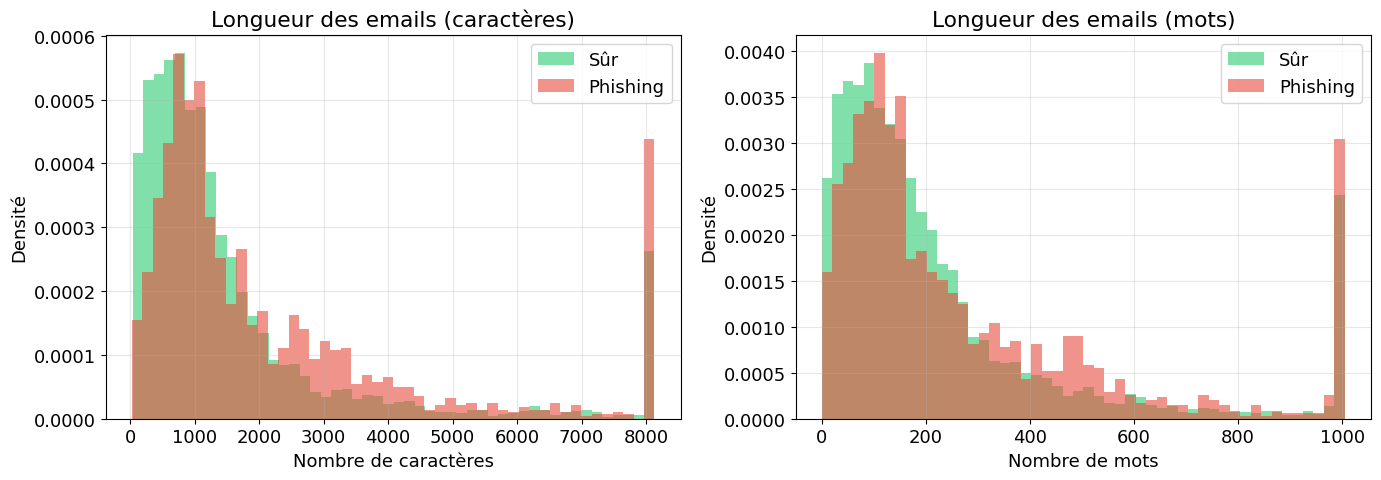

In [ ]:
# On crée 2 graphiques côte à côte.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# On sépare les emails sûrs et phishing dans deux variables.
safe = df[df["label"] == 0]
phish = df[df["label"] == 1]

# On plafonne au 95e percentile : on ignore les 5% d'emails les plus longs
# pour que le graphique ne soit pas écrasé par quelques valeurs extrêmes.
cap_chars = int(df["num_chars"].quantile(0.95))
safe_chars = safe["num_chars"].clip(upper=cap_chars)
phish_chars = phish["num_chars"].clip(upper=cap_chars)
# Même chose mais pour le nombre de mots.
cap_words = int(df["num_words"].quantile(0.95))
safe_words = safe["num_words"].clip(upper=cap_words)
phish_words = phish["num_words"].clip(upper=cap_words)

# Essaie de dessiner un histogramme qui montre combien d'emails ont une certaine longueur
# Cherche la bonne fonction à utiliser dans matplotlib pour dessiner l'histogramme.
# Remarque : utilise bins=50, alpha=0.6, density=True.
# alpha=0.6 rend les barres semi-transparentes pour qu'on puisse voir les deux classes superposées.
# density=True normalise les barres pour comparer les formes même si les tailles sont différentes.
axes[0].hist(...)
axes[0].hist(safe["num_chars"].clip(upper=cap_chars), bins=50,
             alpha=0.6, color=COLORS["safe"], label="Sûr", density=True)
axes[0].hist(phish["num_chars"].clip(upper=cap_chars), bins=50,
             alpha=0.6, color=COLORS["phishing"], label="Phishing", density=True)
axes[0].set_xlabel("Nombre de caractères")
axes[0].set_ylabel("Densité")
axes[0].set_title("Longueur des emails (caractères)")
axes[0].legend()

# Même chose mais pour le nombre de mots.
axes[1].hist(safe["num_words"].clip(upper=cap_words), bins=50,
             alpha=0.6, color=COLORS["safe"], label="Sûr", density=True)
axes[1].hist(phish["num_words"].clip(upper=cap_words), bins=50,
             alpha=0.6, color=COLORS["phishing"], label="Phishing", density=True)
axes[1].set_xlabel("Nombre de mots")
axes[1].set_ylabel("Densité")
axes[1].set_title("Longueur des emails (mots)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Boîtes à moustaches pour une autre vue

Les boîtes à moustaches (box plots) montrent la **médiane** (trait au milieu),
l'**écart interquartile** (la boîte, couvrant du 25e au 75e percentile), et les
**valeurs aberrantes** (points).

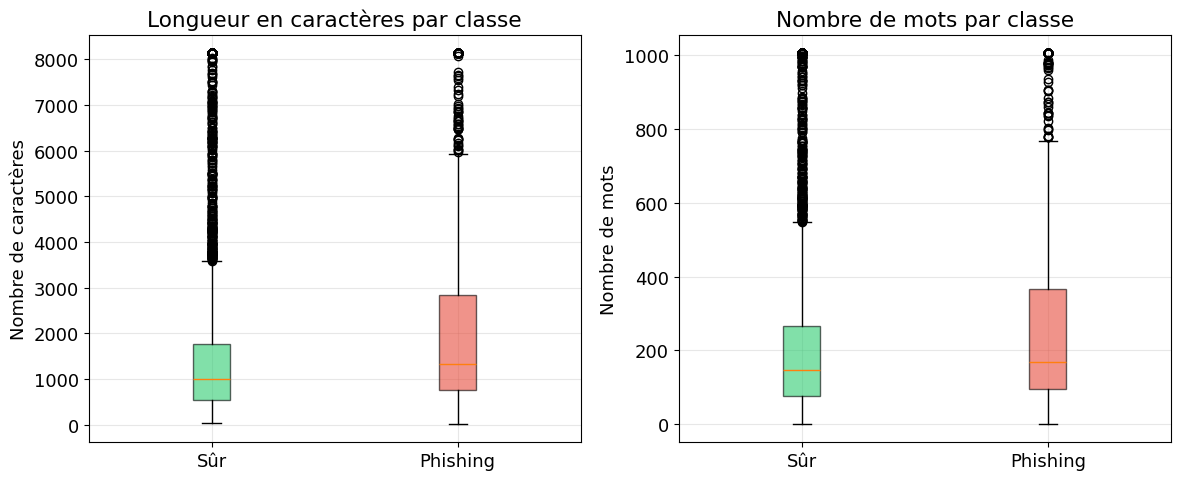

In [ ]:
# On crée 2 graphiques côte à côte pour les boites à moustaches.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Une boîte à moustaches résume la distribution des données :
# - La boîte montre où se trouvent 50% des valeurs (du 25e au 75e percentile).
# - La ligne au milieu de la boîte = la médiane.
# - Les "moustaches" montrent l'étendue des données.
# - Les points au-delà = des valeurs extrêmes (outliers).

# Essaie de dessiner une boîte à moustaches du nombre de caractères.
# Cherche la bonne fonction à utiliser dans matplotlib pour dessiner la boîte à moustaches.
# Remarque : utilise patch_artist=True pour pouvoir colorer les boîtes.
data_chars = [safe["num_chars"].clip(upper=cap_chars),
              phish["num_chars"].clip(upper=cap_chars)]
bp1 = axes[0].boxplot(data_chars, labels=["Sûr", "Phishing"], patch_artist=True)
# On colorie chaque boîte avec la couleur de sa classe.
for patch, color in zip(bp1["boxes"], [COLORS["safe"], COLORS["phishing"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel("Nombre de caractères")
axes[0].set_title("Longueur en caractères par classe")

# Essaie de dessiner une boîte à moustaches du nombre de mots.
data_words = [safe["num_words"].clip(upper=cap_words),
              phish["num_words"].clip(upper=cap_words)]
bp2 = axes[1].boxplot(data_words, labels=["Sûr", "Phishing"], patch_artist=True)
for patch, color in zip(bp2["boxes"], [COLORS["safe"], COLORS["phishing"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel("Nombre de mots")
axes[1].set_title("Nombre de mots par classe")

plt.tight_layout()
plt.show()

### Question pour toi

- Les emails de phishing sont-ils généralement plus courts ou plus longs que les emails sûrs ?
- La longueur de l'email à elle seule pourrait-elle être un bon critère de classification ? Pourquoi ou pourquoi pas ?

**Réponse** :

- **Plus courts ou plus longs ?** Compare les **moyennes et médianes** imprimées juste au-dessus pour chaque classe. Sur ce notebook, on observe souvent que les emails **phishing** ont une **moyenne** (caractères et mots) **plus élevée** que les emails **sûrs**, tout en ayant des **médianes** plus proches — les deux distributions **se chevauchent** sur les histogrammes : il y a des sûrs très longs et des phishing courts.
- **La longueur seule ?** **Non**, ce n'est **pas un bon critère à lui seul** : la variabilité est grande des deux côtés. La longueur peut être un **petit signal** pour un modèle, mais le **contenu** (mots, liens, ton) compte bien plus.

---

## 3 — Nettoyage du texte (tokenisation)

Avant de pouvoir compter les mots, il faut **nettoyer le texte**. Les emails bruts
contiennent des majuscules, de la ponctuation, des chiffres et des caractères spéciaux
qui ne nous aident pas à distinguer le phishing du sûr.

La **tokenisation** est le processus qui consiste à :
1. Tout convertir en minuscules
2. Supprimer la ponctuation et les caractères spéciaux
3. Découper en mots individuels (appelés *tokens*)
4. Supprimer les mots très courants qui ne portent pas de sens (*stop words*)
   comme \"the\", \"is\", \"and\", \"to\", etc.

Voyons un exemple :

> **Note :** Comme notre jeu de données est en anglais, les *stop words* sont également en anglais.

In [ ]:
# --- Stop words (mots vides) ---
# Ce sont des mots très courants (en anglais) comme "the", "is", "and", etc.
# Ils n'aident pas à distinguer un email sûr d'un phishing, donc on les retire.
# set() les stocke dans un ensemble, ce qui rend la recherche très rapide.

STOP_WORDS = set("""
a about above after again against all am an and any are aren't as at be because
been before being below between both but by can can't cannot could couldn't did
didn't do does doesn't doing don't down during each few for from further get got
had hadn't has hasn't have haven't having he he'd he'll he's her here here's hers
herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's
its itself let's me more most mustn't my myself no nor not of off on once only or
other ought our ours ourselves out over own same shan't she she'd she'll she's
should shouldn't so some such than that that's the their theirs them themselves
then there there's these they they'd they'll they're they've this those through to
too under until up us very was wasn't we we'd we'll we're we've were weren't what
what's when when's where where's which while who who's whom why why's will with
won't would wouldn't you you'd you'll you're you've your yours yourself yourselves
""".split())

def clean_text(text):
    """Nettoie un email en plusieurs étapes."""
    # 1. Tout mettre en minuscules pour que "URGENT" et "urgent" soient traités pareil.
    # Cherche la fonction à utiliser dans python pour mettre un texte en minuscules.
    text = text.lower()
    # 2. Retirer tout ce qui n'est pas une lettre ou un espace (chiffres, ponctuation, liens...).
    #    re.sub() remplace les caractères qui correspondent au motif par un espace.
    text = re.sub(r"[^a-z\s]", " ", text)
    # 3. Découper le texte en une liste de mots (= "tokens").
    # Rappelle-toi de la fonction à utiliser dans python pour découper un texte en mots.
    tokens = text.split()
    # 4. Ne garder que les mots utiles : 
    # Essaie de retirer les stop words et les mots de 1-2 lettres.
    # Autrement dit, garde uniquement les mots qui ne sont pas dans STOP_WORDS
    # et qui ont plus de 2 lettres.
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return tokens

# On teste la fonction sur un exemple pour voir ce qu'elle fait.
sample = "URGENT!! Click here to verify your PayPal account: http://evil-link.com/steal"
print("Original :")
print(f"  {sample}")
print("\nAprès nettoyage :")
print(f"  {clean_text(sample)}")

Original :
  URGENT!! Click here to verify your PayPal account: http://evil-link.com/steal

Après nettoyage :
  ['urgent', 'click', 'verify', 'paypal', 'account', 'http', 'evil', 'link', 'com', 'steal']


In [ ]:
# On applique la fonction clean_text() à chaque email du tableau.
# .apply() exécute la fonction sur chaque ligne, une par une.
# Le résultat (une liste de mots) est stocké dans une nouvelle colonne "tokens".
df["tokens"] = df["text"].apply(clean_text)

# On compte le nombre de tokens (mots utiles) par email.
df["num_tokens"] = df["tokens"].apply(len)

# On affiche les 3 premiers emails pour vérifier que le nettoyage fonctionne bien.
# [:15] ne montre que les 15 premiers mots pour ne pas surcharger l'affichage.
print("Les 3 premiers emails après tokenisation :\n")
for i, row in df.head(3).iterrows():
    tag = "PHISHING" if row["label"] == 1 else "SÛR"
    print(f"[{tag}] {row['tokens'][:15]}...")
    print()

Les 3 premiers emails après tokenisation :

[SÛR] ['james', 'rogers', 'writes', 'aren', 'selling', 'software', 'pretty', 'pricy', 'happens', 'using', 'optimize', 'next', 'generation', 'wireless', 'canopies']...

[SÛR] ['tenuous', 'time', 'microsoft', 'gartenberg', 'said', 'time', 'microsoft', 'history', 'seen', 'trying', 'real', 'netscape', 'rrrrrrriiiiiight', 'http', 'www']...

[SÛR] ['rigged', 'testing', 'commit', 'sitewide', 'rollout', 'spamassassin', 'smtp', 'relay', 'work', 'avoids', 'sitewide', 'changes', 'mail', 'delivery', 'early']...



---

## 4 — Mots les plus fréquents par classe

Comptons maintenant quels mots apparaissent le plus souvent dans les emails
**sûrs** vs. les emails de **phishing**. Si certains mots sont beaucoup plus
fréquents dans une classe, un modèle pourrait les utiliser comme indices.

In [ ]:
# Cette fonction compte les mots les plus fréquents dans une classe donnée.
def get_top_words(dataframe, label, n=20):
    """Compte les mots les plus fréquents pour un label donné."""
    # On filtre le tableau pour ne garder que la classe voulue (sûr ou phishing).
    subset = dataframe[dataframe["label"] == label]
    # On rassemble TOUS les mots de TOUS les emails de cette classe en une seule grande liste.
    all_tokens = [token for tokens in subset["tokens"] for token in tokens]
    # Essaie de chercher une classe qui compte la fréquence des mots dans la liste 
    # (le nombre de fois que chaque mot apparaît dans la liste).
    frequence_mots = Counter(all_tokens)
    # Puis trouve une fonction qui renvoie les n mots les plus fréquents.
    n_mots_plus_frequent = frequence_mots.most_common(n)
    return n_mots_plus_frequent

# On récupère le top 20 des mots pour chaque classe.
top_safe = get_top_words(df, label=0, n=20)
top_phish = get_top_words(df, label=1, n=20)

print("Top 20 des mots dans les emails SÛRS :")
for word, count in top_safe:
    print(f"  {word:20s} {count:>6,}")

print("\nTop 20 des mots dans les emails de PHISHING :")
for word, count in top_phish:
    print(f"  {word:20s} {count:>6,}")

Top 20 des mots dans les emails SÛRS :
  http                 18,767
  com                  17,034
  www                  10,875
  gif                   7,017
  cnet                  5,460
  net                   4,430
  list                  3,987
  linux                 3,920
  one                   2,739
  users                 2,560
  zdnet                 2,470
  home                  2,463
  listinfo              2,421
  just                  2,403
  lists                 2,362
  use                   2,269
  new                   2,240
  like                  2,027
  now                   2,016
  org                   1,940

Top 20 des mots dans les emails de PHISHING :
  com                   3,831
  http                  3,761
  email                 2,764
  free                  2,532
  www                   2,425
  click                 1,838
  mail                  1,766
  please                1,698
  business              1,567
  money                 1,540
  one         

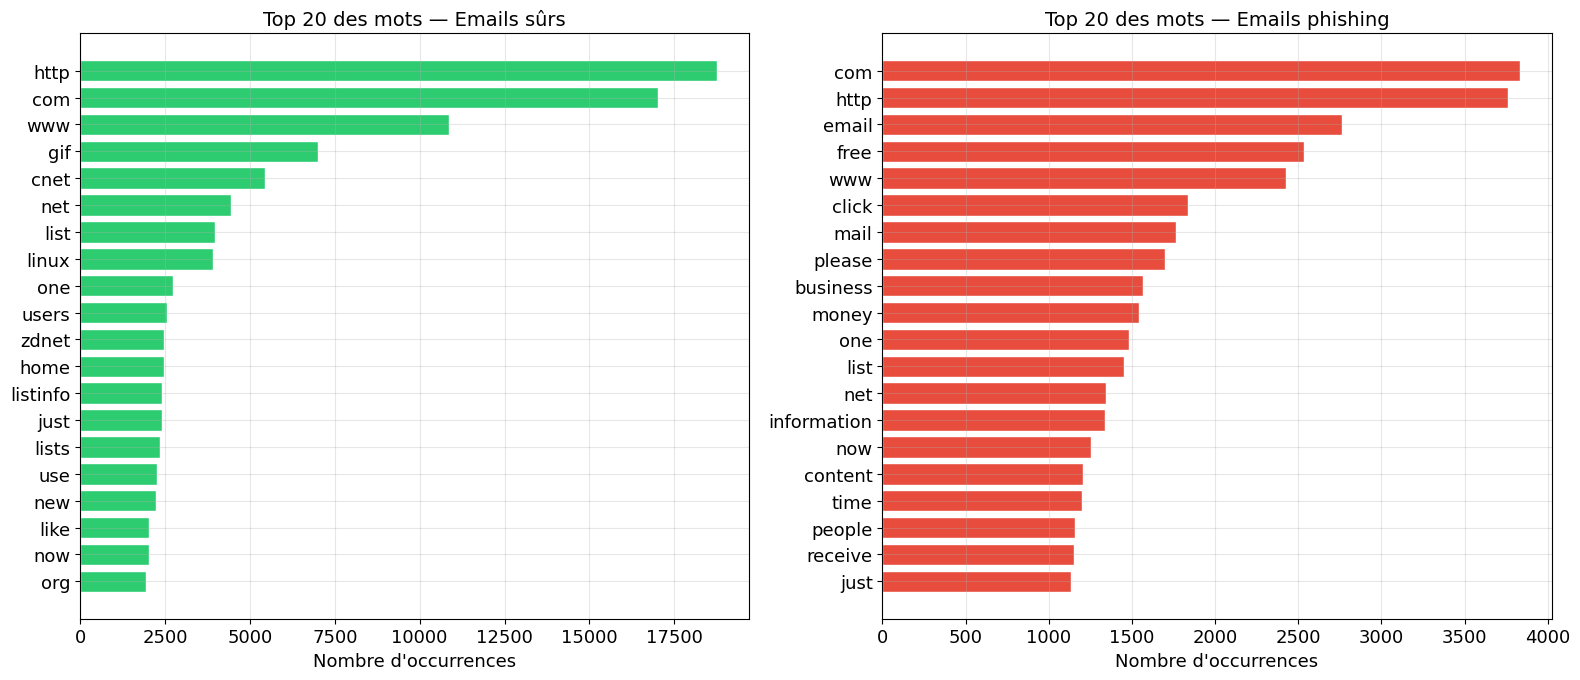

In [ ]:
# On crée 2 graphiques côte à côte pour afficher les mots les plus fréquents.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# zip(*reversed(...)) inverse l'ordre pour que le mot le plus fréquent soit en haut.
# .barh() dessine des barres horizontales (h = horizontal).
words_s, counts_s = zip(*reversed(top_safe))
axes[0].barh(words_s, counts_s, color=COLORS["safe"], edgecolor="white")
axes[0].set_title("Top 20 des mots — Emails sûrs", fontsize=14)
axes[0].set_xlabel("Nombre d'occurrences")

words_p, counts_p = zip(*reversed(top_phish))
axes[1].barh(words_p, counts_p, color=COLORS["phishing"], edgecolor="white")
axes[1].set_title("Top 20 des mots — Emails phishing", fontsize=14)
axes[1].set_xlabel("Nombre d'occurrences")

plt.tight_layout()
plt.show()

### Mots *distinctifs* de chaque classe

Les listes de mots fréquents ci-dessus partagent probablement beaucoup de
mots communs. Ce qui nous intéresse vraiment, ce sont les mots qui
apparaissent **beaucoup plus dans une classe que dans l'autre**.

Ci-dessous, on calcule un ratio simple : pour chaque mot, on regarde à quel
point il est plus fréquent dans le phishing vs. le sûr (et inversement).

In [ ]:
# On rassemble tous les mots de chaque classe dans une grande liste.
safe_tokens = [t for tokens in df[df["label"]==0]["tokens"] for t in tokens]
phish_tokens = [t for tokens in df[df["label"]==1]["tokens"] for t in tokens]

# Counter() compte combien de fois chaque mot apparaît.
safe_freq = Counter(safe_tokens)
phish_freq = Counter(phish_tokens)

# On calcule le nombre total de mots dans chaque classe.
total_safe = sum(safe_freq.values())
total_phish = sum(phish_freq.values())

# L'ensemble de TOUS les mots qui apparaissent (dans les deux classes réunies).
all_words = set(safe_freq.keys()) | set(phish_freq.keys())

# On ne garde que les mots qui apparaissent au moins 30 fois (pour éviter le bruit).
MIN_COUNT = 30
ratios = {}
for word in all_words:
    sc = safe_freq.get(word, 0)
    pc = phish_freq.get(word, 0)
    if sc + pc < MIN_COUNT:
        continue
    # On calcule la fréquence relative du mot dans chaque classe.
    safe_rate = sc / total_safe
    phish_rate = pc / total_phish
    # Le ratio indique combien de fois le mot est plus fréquent en phishing qu'en sûr.
    # Ex: ratio = 5.0 → le mot est 5x plus fréquent dans les emails de phishing.
    ratios[word] = phish_rate / (safe_rate + 1e-10)

# On trie pour trouver les mots les plus indicatifs de chaque classe.
most_phishy = sorted(ratios.items(), key=lambda x: x[1], reverse=True)[:15]
most_safe = sorted(ratios.items(), key=lambda x: x[1])[:15]

print("Mots les plus indicatifs de PHISHING :")
for word, ratio in most_phishy:
    print(f"  {word:20s}  {ratio:>6.1f}x plus fréquent dans le phishing")

print("\nMots les plus indicatifs de SÛR :")
for word, ratio in most_safe:
    r = 1 / (ratio + 1e-10)
    print(f"  {word:20s}  {r:>6.1f}x plus fréquent dans le sûr")

Mots les plus indicatifs de PHISHING :
  cfont                 16032275.8x plus fréquent dans le phishing
  ffont                 16032275.8x plus fréquent dans le phishing
  nbsp                  12652612.9x plus fréquent dans le phishing
  yni                   8322419.8x plus fréquent dans le phishing
  dqo                   7752101.7x plus fréquent dans le phishing
  darial                7350766.8x plus fréquent dans le phishing
  enenkio               5301846.1x plus fréquent dans le phishing
  zvbnq                 5280723.2x plus fréquent dans le phishing
  udd                   4604790.7x plus fréquent dans le phishing
  cbr                   4034472.6x plus fréquent dans le phishing
  awr                   3802120.7x plus fréquent dans le phishing
  aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa  3717629.2x plus fréquent dans le phishing
  xvcj                  3654260.5x plus fréquent dans le phishing
  ftd                   3231802.6x plus fréq

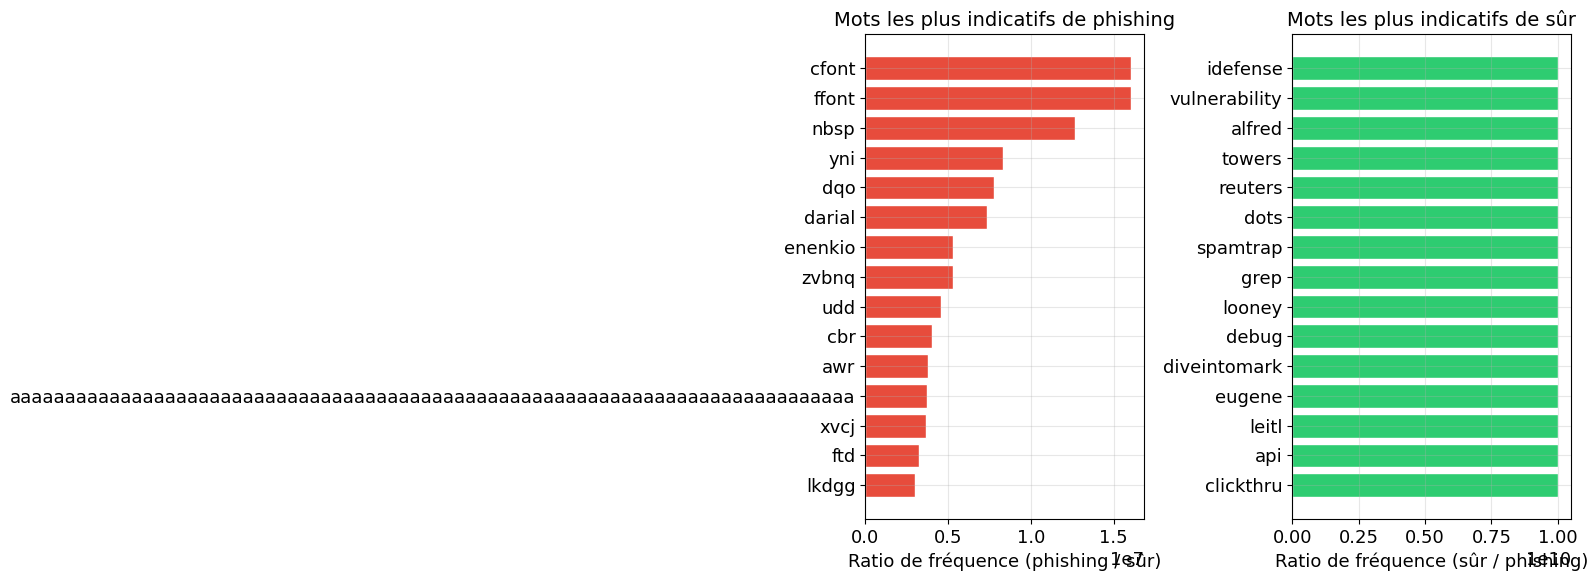

In [ ]:
# On affiche les mots les plus caractéristiques de chaque classe.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique de gauche : mots typiques du phishing.
words_ph, ratios_ph = zip(*reversed(most_phishy))
axes[0].barh(words_ph, ratios_ph, color=COLORS["phishing"], edgecolor="white")
axes[0].set_title("Mots les plus indicatifs de phishing", fontsize=14)
axes[0].set_xlabel("Ratio de fréquence (phishing / sûr)")

# Graphique de droite : mots typiques des emails sûrs.
# On inverse le ratio (1/ratio) pour afficher "combien de fois plus fréquent en sûr".
words_sf, ratios_sf = zip(*reversed(most_safe))
safe_ratios_display = [1/(r+1e-10) for r in ratios_sf]
axes[1].barh(words_sf, safe_ratios_display, color=COLORS["safe"], edgecolor="white")
axes[1].set_title("Mots les plus indicatifs de sûr", fontsize=14)
axes[1].set_xlabel("Ratio de fréquence (sûr / phishing)")

plt.tight_layout()
plt.show()

### Question pour toi

- Les \"mots de phishing\" correspondent-ils aux signaux d'alerte que tu as appris dans le Notebook 0 ?
- Peux-tu imaginer un email sûr qui contiendrait accidentellement des \"mots de phishing\" ?

**Réponse** :

- **Lien avec le Notebook 0 :** Oui, souvent : on retrouve des thèmes comme l'**urgence**, l'**argent**, les **comptes à vérifier**, les **liens** à cliquer, etc. Ce ne sont pas toujours les mêmes mots exacts (le jeu est en anglais, nettoyé), mais l'idée est la même.
- **Email sûr avec des « mots de phishing » :** Oui, facilement. Exemples : une **newsletter** qui écrit *« limited time offer »*, un **mail du service IT** de l'école qui demande de *« vérifier votre mot de passe »* (sans lien douteux), ou une **alerte bancaire légitime** qui parle de *« sécurité du compte »*. Le mot seul ne suffit pas : il faut le **contexte** (expéditeur, lien, ton).

---

## 5 — Motifs spéciaux

Au-delà des mots individuels, les emails de phishing contiennent souvent des
**motifs** spécifiques : des URLs, des adresses email, des mentions d'argent,
des mots d'urgence, etc.

Vérifions-en quelques-uns.

In [ ]:
# Cette fonction compte combien de fois un motif (pattern) apparaît dans un texte.
# re.findall() cherche toutes les correspondances d'une expression régulière (regex).
def count_pattern(text, pattern):
    """Compte combien de fois un motif regex apparaît dans le texte."""
    return len(re.findall(pattern, text, re.IGNORECASE))

# On crée 4 nouvelles colonnes True/False : est-ce que l'email contient ce type de motif ?
# re.search() renvoie True si le motif est trouvé au moins une fois.

# 1. L'email contient-il une URL (http:// ou www.) ?
# Cherche sur le net une expression régulière qui correspond à une URL typique.
df["has_url"] = df["text"].apply(lambda x: bool(re.search(
    r"https?://|www\.", x, re.IGNORECASE)))

# 2. L'email contient-il des mots d'urgence (urgent, immediately, act now...) ?
# Propose des mots qui peuvent correspondre à ce motif, sépare les par |
df["has_urgency"] = df["text"].apply(lambda x: bool(re.search(
    r"urgent|immediately|right away|act now|expires|suspended|limited time|hurry",
    x, re.IGNORECASE)))

# 3. L'email parle-t-il d'argent (dollar, payment, bank account...) ?
# Propose des mots qui peuvent correspondre à ce motif, sépare les par |
df["has_money"] = df["text"].apply(lambda x: bool(re.search(
    r"\$|dollar|money|payment|credit card|bank account|wire transfer|bitcoin",
    x, re.IGNORECASE)))

# 4. L'email contient-il "click here" ou une variante ?
# Propose des mots qui peuvent correspondre à ce motif, sépare les par |
df["has_click"] = df["text"].apply(lambda x: bool(re.search(
    r"click here|click below|click the link|click this",
    x, re.IGNORECASE)))

# On regroupe les noms des colonnes et leurs labels lisibles.
features = ["has_url", "has_urgency", "has_money", "has_click"]
feature_names = ["Contient URL", "Mots d'urgence", "Lié à l'argent", "'Click here'"]

# On affiche le pourcentage d'emails contenant chaque motif, par classe.
# .mean() sur une colonne True/False donne le pourcentage de True.
print(f"{'Motif':<20s} {'Sûr %':>10s} {'Phishing %':>12s}")
print("─" * 44)
for feat, name in zip(features, feature_names):
    safe_pct = 100 * df[df["label"]==0][feat].mean()
    phish_pct = 100 * df[df["label"]==1][feat].mean()
    print(f"{name:<20s} {safe_pct:>9.1f}% {phish_pct:>11.1f}%")

Motif                     Sûr %   Phishing %
────────────────────────────────────────────
Contient URL              87.2%        60.8%
Mots d'urgence             3.1%        16.9%
Lié à l'argent            15.9%        50.8%
'Click here'               2.3%        40.2%


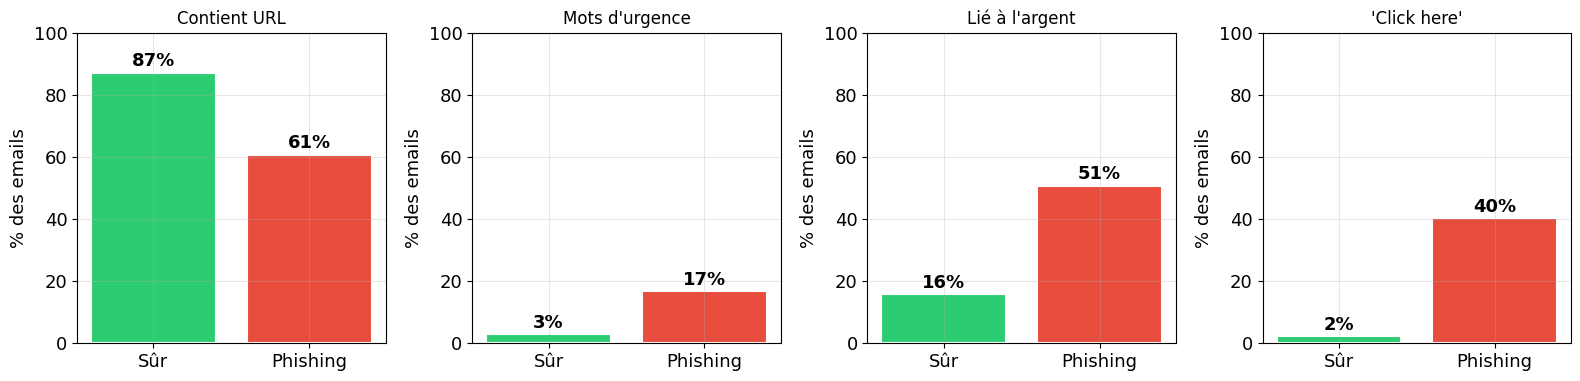

In [ ]:
# On crée un graphique en barres pour chaque motif (4 graphiques côte à côte).
fig, axes = plt.subplots(1, len(features), figsize=(16, 4))

# zip() permet de parcourir les 3 listes en parallèle (axe, nom de colonne, label).
for ax, feat, name in zip(axes, features, feature_names):
    safe_pct = 100 * df[df["label"]==0][feat].mean()
    phish_pct = 100 * df[df["label"]==1][feat].mean()
    bars = ax.bar(["Sûr", "Phishing"], [safe_pct, phish_pct],
                  color=[COLORS["safe"], COLORS["phishing"]],
                  edgecolor="white", linewidth=1.5)
    ax.set_title(name, fontsize=12)
    ax.set_ylabel("% des emails")
    ax.set_ylim(0, 100)
    # On écrit le pourcentage exact au-dessus de chaque barre.
    for bar, pct in zip(bars, [safe_pct, phish_pct]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{pct:.0f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Question pour toi

- Quel motif est le plus fort indicateur de phishing ?
- Est-ce que l'un de ces motifs pourrait provoquer des **fausses alertes** sur des emails sûrs ? Donne un exemple.

**Réponse** :

- **Motif le plus fort :** En général, sur ce type d'analyse, **« click here » / incitation à cliquer** et les **mots d'urgence** ressortent souvent **plus souvent en phishing** ; les **URL** sont aussi très fréquentes en phishing (mais aussi dans beaucoup d'emails sûrs). La réponse exacte dépend des **pourcentages** affichés dans ton tableau : indique le motif avec la **plus grande différence** entre phishing et sûr.
- **Fausse alerte (faux positif) :** Oui. Exemple : un **mail de confirmation Amazon ou de transport** avec une **URL** de suivi, un **rappel de rendez-vous** avec *« act now »* ou *« urgent »*, ou une **newsletter** avec *« click here to unsubscribe »*. Un filtre trop agressif pourrait les marquer à tort comme phishing.

---

## 6 — Inspection des échantillons suspects

Les jeux de données du monde réel sont imparfaits. Certains emails peuvent être :
- **Mal étiquetés** (un email sûr marqué comme phishing, ou l'inverse)
- **Ambiguës** (pourraient être l'un ou l'autre)
- **Bruités** (texte corrompu, très court, ou non pertinent)

Regardons quelques échantillons potentiellement problématiques.

### Emails très courts

Les emails avec très peu de mots pourraient manquer d'informations suffisantes pour la classification.

In [ ]:
# Essaie de trouver une fonction qui permet de sélectionner les 10 emails avec le moins de mots.
short_emails = df.nsmallest(10, "num_words")[["text", "label", "num_words"]]

print("Les 10 emails les plus courts du jeu de données :\n")
for _, row in short_emails.iterrows():
    tag = "PHISHING" if row["label"] == 1 else "SÛR"
    # On affiche seulement les 120 premiers caractères pour garder l'affichage compact.
    text_preview = row["text"][:120].replace("\n", " ")
    print(f"  [{tag:8s}] ({row['num_words']:3d} mots)  {text_preview}")

Les 10 emails les plus courts du jeu de données :

  [PHISHING] (  1 mots)  http://xent.com/mailman/listinfo/fork
  [SÛR     ] (  1 mots)  http://www.post-gazette.com/columnists/20020905brian5.asp
  [PHISHING] (  2 mots)  ![](http://master2.free4all.com/cgi-bin/sp/t.pl?id=7:56446664&o=1&d=1) ![](http://www.vitafactory.com/ad-friday/test.gif
  [PHISHING] (  2 mots)  .  ukqdrblkougooeoffnxsmbowei
  [PHISHING] (  3 mots)  ![](http://members.aol.com/tjoyce/mail_01.gif)   ![](http://members.aol.com/tjoyce/mail_02.gif) 4623
  [PHISHING] (  3 mots)  Click Here hwawrlgiooooqvjoii
  [PHISHING] (  3 mots)  ![](http://master2.free4all.com/cgi- bin/sp/t.pl?id=6:56446664&o=1&d=1)![](http://www.vitafactory.com/ad- friday/test.gi
  [SÛR     ] (  5 mots)  URL: http://www.newsisfree.com/click/-1,8410270,1717/ Date: 2002-09-30T22:21:11+01:00  (DPO)
  [SÛR     ] (  5 mots)  URL: http://www.newsisfree.com/click/-1,8410272,1717/ Date: 2002-09-30T22:21:09+01:00  (Philly.com)
  [PHISHING] (  5 mots)  ViaPro 

### Emails très longs

Les emails extrêmement longs peuvent contenir beaucoup de texte générique
(boilerplate) ou être des messages multi-parties avec des en-têtes.

In [ ]:
# Essaie de trouver une fonction qui permet de sélectionner les 10 emails avec le plus de mots.
long_emails = df.nlargest(5, "num_words")[["text", "label", "num_words"]]

print("Les 5 emails les plus longs du jeu de données :\n")
for _, row in long_emails.iterrows():
    tag = "PHISHING" if row["label"] == 1 else "SÛR"
    text_preview = row["text"][:150].replace("\n", " ")
    print(f"  [{tag:8s}] ({row['num_words']:,} mots)  {text_preview}...")

Les 5 emails les plus longs du jeu de données :

  [SÛR     ] (14,952 mots)  "Free trade and free markets have proven their ability to lift whole societies out of poverty" I'm not a socio-political/history buff - does anybody h...
  [SÛR     ] (14,859 mots)  ------------------------ Yahoo! Groups Sponsor ---------------------~--> 4 DVDs Free +s&p Join Now http://us.click.yahoo.com/pt6YBB/NXiEAA/Ey.GAA/26Eo...
  [SÛR     ] (13,221 mots)  > A world where some live in comfort and plenty, while half of the human  > race lives on less than $2 a day, is neither just nor stable.  Absolutely ...
  [SÛR     ] (12,840 mots)  ::: L I N K S   F O R   T H E   D A Y :::  Today's news on the web: http://freshmeat.net/daily/2002/07/30/ freshmeat.net newsgroup: news://news.freshm...
  [PHISHING] (11,620 mots)  Reply From EnenKio The following message was recieved Saturday, 13 July 2002.=20 Nothing has been amdended or changed. I hold no responcibility for th...


### Potentiellement mal étiquetés : emails sûrs avec beaucoup de mots-clés de phishing

In [ ]:
import textwrap

# Une liste de mots-clés typiques du phishing.
phishing_keywords = ["urgent", "verify", "suspended", "click here",
                     "confirm your", "password", "act now", "limited time"]

# Cette fonction compte combien de mots-clés de phishing apparaissent dans un email.
def count_phishing_keywords(text):
    text_lower = text.lower()
    # sum(1 for ...) compte le nombre de mots-clés trouvés dans le texte.
    return sum(1 for kw in phishing_keywords if kw in text_lower)

# On applique cette fonction à chaque email et on stocke le résultat.
df["phishing_keyword_count"] = df["text"].apply(count_phishing_keywords)

# On cherche des emails étiquetés SÛRS mais qui contiennent au moins 2 mots-clés de phishing.
# Ce sont des cas intéressants : soit mal étiquetés, soit des emails légitimes
# qui utilisent un langage similaire au phishing.
suspicious_safe = (df[(df["label"] == 0) & (df["phishing_keyword_count"] >= 2)]
                   .nlargest(3, "phishing_keyword_count"))

print("Emails sûrs qui contiennent beaucoup de mots-clés de type phishing :\n")
print("(Ils pourraient être mal étiquetés, ou ce sont des emails légitimes")
print(" qui utilisent simplement un langage similaire.)\n")

for _, row in suspicious_safe.iterrows():
    print(f"{'='*70}")
    print(f"  Label : SÛR  |  Mots-clés phishing trouvés : {row['phishing_keyword_count']}")
    print(f"{'='*70}")
    print(textwrap.fill(row["text"][:400], width=70))
    print()

Emails sûrs qui contiennent beaucoup de mots-clés de type phishing :

(Ils pourraient être mal étiquetés, ou ce sont des emails légitimes
 qui utilisent simplement un langage similaire.)

  Label : SÛR  |  Mots-clés phishing trouvés : 3
SecurityFocus Linux Newsletter #92 ----------------------------------
This newsletter is sponsored by: SecurityFocus DeepSight Threat
Management System  >>From June 24th - August 31st, 2002, SecurityFocus
announces a FREE two-week trial of the DeepSight Threat Management
System: the only early warning system providing customizable and
comprehensive early warning of cyber attacks and bulletproof c

  Label : SÛR  |  Mots-clés phishing trouvés : 3
Today's Headlines from The Register
-----------------------------------      To unsubscribe from this
daily news update, see the instructions at     the end of this
message.
--------ADVERTISEMENT------------------------------------------------
WIN tickets to a FORMULA ONE EUROPEAN GRAND PRIX!    Neverfail Group


### Question pour toi

- Penses-tu que certains des emails ci-dessus sont mal étiquetés ? Pourquoi ?
- Pourquoi est-il important d'être conscient des données bruitées ou mal étiquetées
  avant d'entraîner un modèle ?

**Réponse** :

- **Mal étiquetés ?** **Peut-être pour quelques-uns.** Si un email est marqué *sûr* mais ressemble à une arnaque classique (gros héritage, demande d'argent, ton très suspect), il est possible qu'il soit **mal classé** dans le jeu de données. À l'inverse, certains restent **légitimes** mais utilisent le même vocabulaire qu'une arnaque (newsletter, alerte sécurité réelle).
- **Pourquoi c'est important ?** Le modèle **apprend des labels**. Si des exemples sont faux, il apprend des **erreurs** : il peut **sur-apprendre** du bruit ou **mal généraliser**. D'où l'intérêt de **contrôler** les données, parfois **corriger** les labels, et interpréter les métriques avec prudence.

---

## 7 — Tableau récapitulatif

Rassemblons toutes nos découvertes dans un dernier résumé.

In [ ]:
# On calcule les statistiques finales pour le résumé.
n_safe = len(df[df["label"] == 0])
n_phish = len(df[df["label"] == 1])

# Statistiques de longueur par classe.
mean_words_safe = df[df["label"]==0]["num_words"].mean()
mean_words_phish = df[df["label"]==1]["num_words"].mean()
median_words_safe = df[df["label"]==0]["num_words"].median()
median_words_phish = df[df["label"]==1]["num_words"].median()
mean_chars_safe = df[df["label"]==0]["num_chars"].mean()
mean_chars_phish = df[df["label"]==1]["num_chars"].mean()

# Pourcentages des motifs par classe.
url_safe = 100 * df[df["label"]==0]["has_url"].mean()
url_phish = 100 * df[df["label"]==1]["has_url"].mean()
urgency_safe = 100 * df[df["label"]==0]["has_urgency"].mean()
urgency_phish = 100 * df[df["label"]==1]["has_urgency"].mean()
money_safe = 100 * df[df["label"]==0]["has_money"].mean()
money_phish = 100 * df[df["label"]==1]["has_money"].mean()
click_safe = 100 * df[df["label"]==0]["has_click"].mean()
click_phish = 100 * df[df["label"]==1]["has_click"].mean()

# Ratio d'équilibre.
balance = min(n_safe, n_phish) / max(n_safe, n_phish)

# Top 3 mots les plus indicatifs de chaque classe.
top3_phishy = ", ".join(w for w, _ in most_phishy[:3])
top3_safe_words = ", ".join(w for w, _ in most_safe[:3])

# Emails suspects.
n_suspicious = len(df[(df["label"] == 0) & (df["phishing_keyword_count"] >= 2)])

# On affiche un joli tableau récapitulatif de tout ce qu'on a découvert.
print("╔════════════════════════════════════════════════════════════════════╗")
print("║              RÉSUMÉ DE L'EXPLORATION DU DATASET                  ║")
print("╠════════════════════════════════════════════════════════════════════╣")
print("║                                                                    ║")
print("║  DISTRIBUTION DES CLASSES                                          ║")
print(f"║    Total emails          : {len(df):>6,}                               ║")
print(f"║    Emails sûrs           : {n_safe:>6,}  ({100*n_safe/len(df):.1f}%)                  ║")
print(f"║    Emails phishing       : {n_phish:>6,}  ({100*n_phish/len(df):.1f}%)                  ║")
print(f"║    Ratio d'équilibre     : {balance:.2f}                                  ║")
print("║                                                                    ║")
print("║  LONGUEUR DES EMAILS                                               ║")
print(f"║    Moy. caractères (sûr)     : {mean_chars_safe:>7,.0f}                          ║")
print(f"║    Moy. caractères (phishing): {mean_chars_phish:>7,.0f}                          ║")
print(f"║    Moy. mots (sûr)          : {mean_words_safe:>7,.0f}                          ║")
print(f"║    Moy. mots (phishing)      : {mean_words_phish:>7,.0f}                          ║")
print(f"║    Médiane mots (sûr)        : {median_words_safe:>7,.0f}                          ║")
print(f"║    Médiane mots (phishing)   : {median_words_phish:>7,.0f}                          ║")
print("║                                                                    ║")
print("║  MOTIFS SUSPECTS (% d'emails contenant le motif)                   ║")
print(f"║                              Sûr        Phishing                   ║")
print(f"║    Contient URL          : {url_safe:>5.1f}%       {url_phish:>5.1f}%                    ║")
print(f"║    Mots d'urgence        : {urgency_safe:>5.1f}%       {urgency_phish:>5.1f}%                    ║")
print(f"║    Lié à l'argent        : {money_safe:>5.1f}%       {money_phish:>5.1f}%                    ║")
print(f"║    'Click here'          : {click_safe:>5.1f}%       {click_phish:>5.1f}%                    ║")
print("║                                                                    ║")
print("║  MOTS LES PLUS CARACTÉRISTIQUES                                    ║")
print(f"║    Phishing : {top3_phishy:<50s}   ║")
print(f"║    Sûr      : {top3_safe_words:<50s}   ║")
print("║                                                                    ║")
print("║  ANOMALIES                                                         ║")
print(f"║    Emails sûrs avec >=2 mots-clés phishing : {n_suspicious}                      ║")
print("║                                                                    ║")
print("╚════════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════╗
║       RÉSUMÉ DE L'EXPLORATION DU DATASET         ║
╠══════════════════════════════════════════════════════╣
║  Total emails          :  5,806                    ║
║  Emails sûrs           :  4,091  (70.5%)           ║
║  Emails phishing       :  1,715  (29.5%)           ║
║                                                      ║
║  Moy. mots (sûr)      :    280                    ║
║  Moy. mots (phishing)  :    359                    ║
║                                                      ║
║  Emails avec URL :                                   ║
║    Sûr      :  87.2%                            ║
║    Phishing :  60.8%                            ║
╚══════════════════════════════════════════════════════╝


---

## 8 — Qu'avons-nous appris ?

Écris quelques phrases résumant tes découvertes :

1. **Équilibre des classes :** Le jeu de données est-il équilibré ? Qu'est-ce que cela implique pour notre modèle ?

2. **Longueur des emails :** Les emails de phishing sont-ils plus courts, plus longs, ou à peu près pareils ?

3. **Mots clés :** Quels mots sont les meilleurs indicateurs de phishing ? D'emails sûrs ?

4. **Motifs :** Quels motifs (URLs, urgence, argent, \"click here\") sont les plus
   utiles pour la détection ?

5. **Qualité des données :** As-tu trouvé des emails bruités ou potentiellement mal étiquetés ?

*Écris ton résumé ici :*

1. ...
2. ...
3. ...
4. ...
5. ...

---

## Résumé

Dans ce notebook, tu as :

- Vérifié l'**équilibre des classes** et compris pourquoi c'est important.
- Comparé les **longueurs d'emails** entre emails sûrs et emails de phishing.
- Appris à **nettoyer du texte** (tokenisation, suppression des stop words).
- Trouvé les **mots les plus distinctifs** pour chaque classe.
- Détecté des **motifs spécifiques** (URLs, urgence, références à l'argent).
- Inspecté des **échantillons bruités et potentiellement mal étiquetés**.

Toutes ces observations nous aideront à comprendre ce que notre modèle
de machine learning va essayer d'apprendre dans le prochain notebook.

**À suivre :** Dans le *Notebook 02*, nous transformerons ces caractéristiques
textuelles en nombres grâce au **TF-IDF** et nous entraînerons nos premiers
classifieurs !